# Tutorial on Decision Trees and Random Forests (Wildfire cause prediction)

A decision tree classifies a sample by asking a sequence of yes-or-no questions about its
features, each one a threshold on a single column. A random forest grows many trees on
different random subsets of the data and lets them vote. This tutorial builds both on real
data and watches what each hyperparameter does.

We use the data set from ["Inference of Wildfire Causes From Their Physical, Biological, Social
and Management Attributes"](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024EF005187)
by Pourmohamad et al., Earth's Future, 2025. The question in that paper is whether the cause
of a wildfire can be inferred, for fires where it was never recorded, from fires where it was.
Half a million fires across the western United States, each with weather, fuel, terrain, and
social attributes at the ignition point.

**Reference:** Pourmohamad, Y., Abatzoglou, J. T., Fleishman, E., Short, K. C., Shuman, J.,
AghaKouchak, A., et al. (2025). Inference of wildfire causes from their physical, biological,
social and management attributes. Earth's Future, 13, e2024EF005187.


In [1]:
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load and clean, quickly

The data set is a 139 MB CSV on [Zenodo](https://zenodo.org/records/11510677). The cell
downloads it once and reuses the local copy afterwards.


In [2]:
FILE = "FPA_FOD_west_cleaned.csv"
if not os.path.exists(FILE):
    print("downloading ...")
    urllib.request.urlretrieve("https://zenodo.org/records/11510677/files/" + FILE, FILE)

data = pd.read_csv(FILE)
print(data.shape)
data.head()

(519689, 40)


,DISCOVERY_DOY,FIRE_YEAR,STATE,FIPS_CODE,NWCG_GENERAL_CAUSE,Annual_etr,Annual_precipitation,Annual_tempreture,pr,tmmn,...,GHM,NDVI-1day,NPL,Popo_1km,RPL_THEMES,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4,Distance2road
0,1,2007,CA,6053.0,Misuse of fire by a minor,1625,257,286.0,0.0,276.500000,...,0.42,0.00,1.0,1.1494,0.055,0.027,0.245,0.039,0.203,43.0
1,1,2007,CA,6019.0,Arson/incendiarism,1819,383,290.0,0.0,273.200012,...,0.35,0.50,1.0,0.1652,0.525,0.719,0.499,0.302,0.405,40.2
2,1,2007,CA,6089.0,Misuse of fire by a minor,2293,985,290.0,0.0,275.100006,...,0.16,0.42,1.0,0.0504,0.476,0.635,0.516,0.002,0.581,43.8
3,1,2007,CA,6089.0,Misuse of fire by a minor,2293,985,290.0,0.0,275.100006,...,0.16,0.42,1.0,0.0504,0.476,0.635,0.516,0.002,0.581,43.8
4,1,2007,CA,6079.0,Debris and open burning,2423,102,289.0,0.0,271.299988,...,0.18,0.16,1.0,0.0718,0.295,0.309,0.321,0.105,0.313,41.0


Each row is one fire. The target is `NWCG_GENERAL_CAUSE`. The other columns are the
attributes at the ignition point: day of year and year, state and county, annual climate
(`Annual_etr`, `Annual_precipitation`, `Annual_tempreture`), the weather that day (`pr`,
`tmmn`, `vs`), fuel moisture and fire danger indices (`fm100`, `fm1000`, `bi`, `vpd`, `erc`,
`erc_Percentile`), terrain (`Elevation_1km`, `Aspect_1km`, `Slope_1km`, `TPI_1km`), vegetation
(`EVC`, `NDVI-1day`, `FRG`), and the social and management setting (population, GDP, distance
to road, fire station within 5 km, land ownership, social vulnerability themes `RPL_*`).


In [3]:
print(data["NWCG_GENERAL_CAUSE"].value_counts())

NWCG_GENERAL_CAUSE
Natural                                       168349
Missing data/not specified/undetermined       150427
Equipment and vehicle use                      48994
Debris and open burning                        40516
Recreation and ceremony                        38665
Arson/incendiarism                             28090
Smoking                                        13547
Misuse of fire by a minor                      11523
Power generation/transmission/distribution      6469
Fireworks                                       6373
Railroad operations and maintenance             3074
Other causes                                    2068
Firearms and explosives use                     1594
Name: count, dtype: int64


A few columns use sentinel values for missing data, which the Week 2 lesson says to replace
with NaN before anything else. Then we drop the incomplete rows.


In [4]:
data.loc[data["GHM"] < 0.0, "GHM"] = np.nan
data.loc[data["SDI"] < 0.0, "SDI"] = np.nan
data["FRG"] = data["FRG"].replace(-9999, np.nan)
for col in ["RPL_THEMES", "RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4"]:
    data[col] = data[col].replace(-999.0, np.nan)

data = data.dropna().reset_index(drop=True)
print("rows with complete attributes:", len(data))

rows with complete attributes: 518659


## 2. Labels: known causes, unknown causes, and natural versus human

About 150,000 fires have no recorded cause. Those are the fires the paper wants to classify,
so we set them aside and train only on the fires whose cause is known. Two labels come out of
the known fires: a binary one, natural (lightning) versus anthropogenic (everything else), and
the full list of causes for later.


In [5]:
UNKNOWN = "Missing data/not specified/undetermined"
data_unknown = data[data["NWCG_GENERAL_CAUSE"] == UNKNOWN].reset_index(drop=True).copy()
data_known = data[data["NWCG_GENERAL_CAUSE"] != UNKNOWN].reset_index(drop=True).copy()

y_binary = (data_known["NWCG_GENERAL_CAUSE"] == "Natural").astype(int).to_numpy()
classnames_binary = ["Anthropogenic", "Natural"]

classnames_multi = sorted(data_known["NWCG_GENERAL_CAUSE"].unique())
y_multi = data_known["NWCG_GENERAL_CAUSE"].map({c: i for i, c in enumerate(classnames_multi)}).to_numpy()

print("known cause:", len(data_known), "  unknown cause:", len(data_unknown))
print("natural fraction among known:", y_binary.mean().round(3))
print("causes:", classnames_multi)

known cause: 368533   unknown cause: 150126
natural fraction among known: 0.456
causes: ['Arson/incendiarism', 'Debris and open burning', 'Equipment and vehicle use', 'Firearms and explosives use', 'Fireworks', 'Misuse of fire by a minor', 'Natural', 'Other causes', 'Power generation/transmission/distribution', 'Railroad operations and maintenance', 'Recreation and ceremony', 'Smoking']


## 3. Features: trees do not need scaling

Trees split on thresholds, "is `erc` above 48?", and a threshold on a column is unchanged by
rescaling that column. So no `StandardScaler`. The only preprocessing is the one text column,
`STATE`, which becomes an integer code. Everything else passes through as it is, which also
keeps the feature names readable in the plots later.


In [6]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

features = data_known.drop(columns=["NWCG_GENERAL_CAUSE"])
features_unknown = data_unknown.drop(columns=["NWCG_GENERAL_CAUSE"])

numerical_cols = [c for c in features.columns if c != "STATE"]
preprocessor = ColumnTransformer([("num", "passthrough", numerical_cols),
                                  ("state", OrdinalEncoder(), ["STATE"])],
                                 verbose_feature_names_out=False)

X_known = preprocessor.fit_transform(features)
X_unknown = preprocessor.transform(features_unknown)      # same encoding, fitted on the known fires
featurenames = preprocessor.get_feature_names_out()
print(X_known.shape, X_unknown.shape)

(368533, 39) (150126, 39)


## 4. Training, validation, and test split

Eighty percent to train, ten to choose hyperparameters on, ten held back. The split is on an
index array so that both label sets, binary and multiclass, follow the same rows.


In [7]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(X_known))
idx_train, idx_rest = train_test_split(idx, test_size=0.2, random_state=42)
idx_val, idx_test = train_test_split(idx_rest, test_size=0.5, random_state=42)

X_train, X_val, X_test = X_known[idx_train], X_known[idx_val], X_known[idx_test]
yb_train, yb_val, yb_test = y_binary[idx_train], y_binary[idx_val], y_binary[idx_test]
ym_train, ym_val, ym_test = y_multi[idx_train], y_multi[idx_val], y_multi[idx_test]
print("train", X_train.shape, " val", X_val.shape, " test", X_test.shape)

train (294826, 39)  val (36853, 39)  test (36854, 39)


## 5. A decision tree

Start with the shallowest useful tree, two levels deep, and draw it. Every box is a question
on one feature. Follow the answers down and you reach a leaf that votes natural or
anthropogenic.


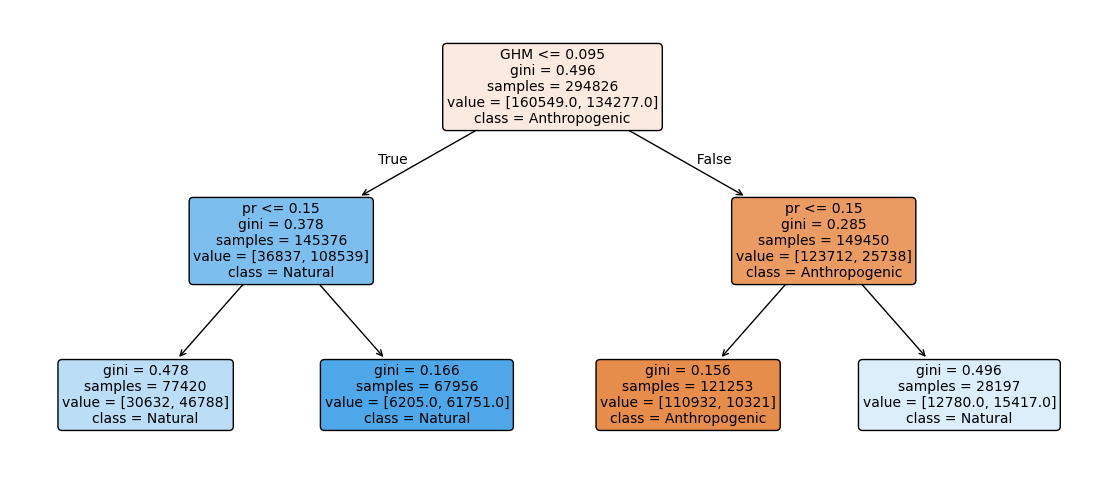

depth-2 tree, validation accuracy: 0.799
always 'anthropogenic' would score:  0.543


In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree2 = DecisionTreeClassifier(max_depth=2, random_state=42)
tree2.fit(X_train, yb_train)

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(tree2, feature_names=featurenames, class_names=classnames_binary,
          filled=True, rounded=True, fontsize=10, ax=ax)
plt.show()

print(f"depth-2 tree, validation accuracy: {tree2.score(X_val, yb_val):.3f}")
print(f"always 'anthropogenic' would score:  {1 - yb_val.mean():.3f}")

Read the root. The first question the tree found is whether `GHM`, the human-modification
index of the land within a kilometre of the ignition point, is below about 0.1: did the fire
start in country that people have barely touched? If so, the tree calls it natural, and it is
right about three times in four, because about 108,000 of the 145,000 such training fires were
lightning. If not, it calls the fire human-caused, unless rain fell that day (`pr` above
0.15 mm), which tilts the odds back toward lightning because thunderstorms bring both. Two
questions on two features already score 80 percent. The `gini` value in each box measures how
mixed the two classes are at that node; a leaf with gini 0 is pure. `samples` is how many
training fires reached the node, `value` how they divide.

**Depth is the knob.** A deeper tree asks more questions and can fit the training data more
closely. Let the depth grow and score each tree on both the training set and the validation
set.


max_depth=   2  actual depth=  2  leaves=      4  train 0.797  validation 0.799


max_depth=   4  actual depth=  4  leaves=     16  train 0.845  validation 0.847


max_depth=   6  actual depth=  6  leaves=     64  train 0.869  validation 0.869


max_depth=   8  actual depth=  8  leaves=    252  train 0.880  validation 0.878


max_depth=  12  actual depth= 12  leaves=  2,470  train 0.907  validation 0.880


max_depth=  16  actual depth= 16  leaves=  8,529  train 0.947  validation 0.874


max_depth=  24  actual depth= 24  leaves= 17,917  train 0.989  validation 0.857


max_depth=None  actual depth= 51  leaves= 22,075  train 1.000  validation 0.848


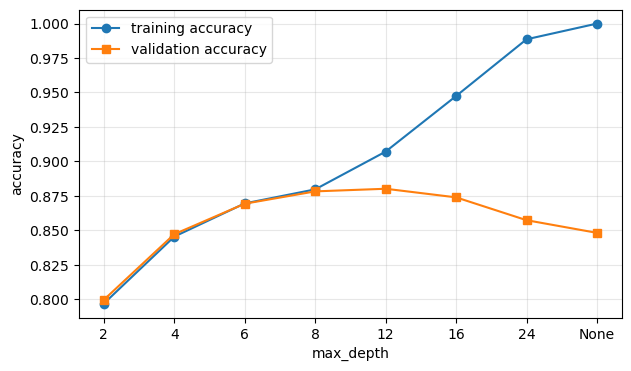

In [9]:
depths = [2, 4, 6, 8, 12, 16, 24, None]      # None = grow until every leaf is pure
train_acc, val_acc, trees = [], [], {}
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, yb_train)
    trees[d] = t
    train_acc.append(t.score(X_train, yb_train))
    val_acc.append(t.score(X_val, yb_val))
    print(f"max_depth={str(d):>4}  actual depth={t.get_depth():>3}  leaves={t.get_n_leaves():>7,}  "
          f"train {train_acc[-1]:.3f}  validation {val_acc[-1]:.3f}")

labels = [str(d) for d in depths]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(labels, train_acc, "o-", label="training accuracy")
ax.plot(labels, val_acc, "s-", label="validation accuracy")
ax.set_xlabel("max_depth"); ax.set_ylabel("accuracy"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

The two curves tell the whole story of overfitting in one picture. Training accuracy climbs
all the way to 1.0: a tree with no depth limit keeps splitting until every training fire sits
in its own pure leaf, and it has memorized the data. Validation accuracy rises, peaks at a
depth of 12, then slips as the extra splits start fitting noise. The gap between the two
curves is the overfit, and it is the signature to look for whenever a model has a complexity
knob.

Pick the depth from the validation curve, never from the training curve, and look at the
confusion matrix of that tree.


best depth on validation: 12


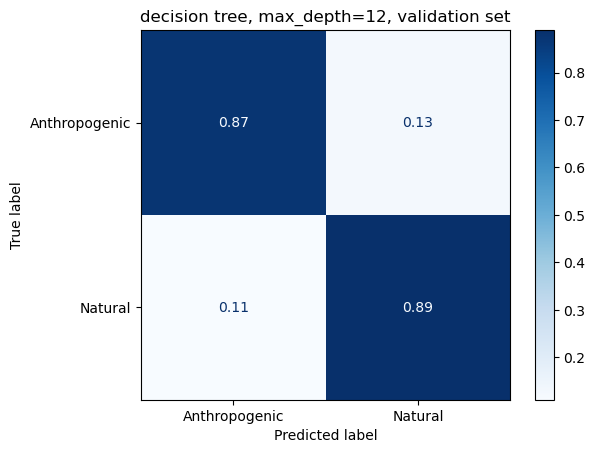

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

best_depth = depths[int(np.argmax(val_acc))]
best_tree = trees[best_depth]
print("best depth on validation:", best_depth)

ConfusionMatrixDisplay.from_estimator(best_tree, X_val, yb_val, normalize="true",
                                      display_labels=classnames_binary, cmap="Blues")
plt.title(f"decision tree, max_depth={best_depth}, validation set")
plt.show()

## 6. A random forest

A single deep tree is unstable: change a few training rows and it grows differently. A random
forest grows many trees, each on a bootstrap sample of the rows and considering only a random
subset of the features at each split, then takes a majority vote. The individual trees overfit;
the vote averages their errors away.


trained 100 trees in 7 s
best single tree, validation accuracy: 0.880
random forest,    validation accuracy: 0.907


random forest,    training accuracy:   1.000


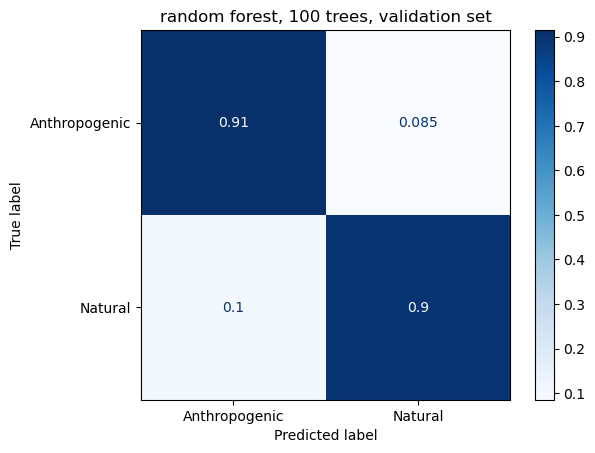

In [11]:
from sklearn.ensemble import RandomForestClassifier
import time

start = time.time()
forest = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
forest.fit(X_train, yb_train)
print(f"trained 100 trees in {time.time() - start:.0f} s")

print(f"best single tree, validation accuracy: {best_tree.score(X_val, yb_val):.3f}")
print(f"random forest,    validation accuracy: {forest.score(X_val, yb_val):.3f}")
print(f"random forest,    training accuracy:   {forest.score(X_train, yb_train):.3f}")

ConfusionMatrixDisplay.from_estimator(forest, X_val, yb_val, normalize="true",
                                      display_labels=classnames_binary, cmap="Blues")
plt.title("random forest, 100 trees, validation set")
plt.show()

The forest beats the best single tree by a few points on validation, and notice its training
accuracy: 1.0. Each tree in the forest is fully grown and memorizes its own bootstrap sample,
yet the vote generalizes better than the carefully depth-limited single tree. Averaging many
overfit models is the idea behind every ensemble method in this course.

**How many trees?** More trees cost time and memory, so it is worth knowing where the returns
flatten out.


In [12]:
for n in [1, 5, 20, 50, 100, 200]:
    start = time.time()
    f = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1).fit(X_train, yb_train)
    print(f"{n:>4} trees: validation accuracy {f.score(X_val, yb_val):.3f}   ({time.time() - start:.0f} s)")

   1 trees: validation accuracy 0.838   (1 s)


   5 trees: validation accuracy 0.887   (1 s)


  20 trees: validation accuracy 0.903   (2 s)


  50 trees: validation accuracy 0.906   (4 s)


 100 trees: validation accuracy 0.907   (7 s)


 200 trees: validation accuracy 0.907   (14 s)


One tree is a deep, overfit decision tree. Five already beat the best pruned single tree.
Past about fifty the gains are a thousandth or less, and the cost is linear in the number of
trees. One hundred is a reasonable default; two hundred is rarely worth it.

## 7. Which features matter?

A forest records, for every split in every tree, how much that split reduced the impurity and
on which feature. Summed over the forest and normalized, that is the feature importance.


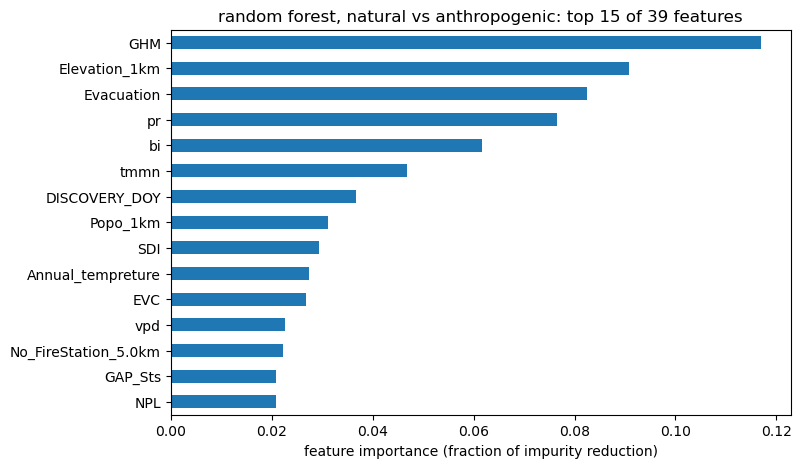

top five: ['GHM', 'Elevation_1km', 'Evacuation', 'pr', 'bi']


In [13]:
importance = pd.Series(forest.feature_importances_, index=featurenames).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importance.head(15).iloc[::-1].plot.barh(ax=ax)
ax.set_xlabel("feature importance (fraction of impurity reduction)")
ax.set_title("random forest, natural vs anthropogenic: top 15 of 39 features")
plt.show()

print("top five:", list(importance.index[:5]))

Human modification of the land within a kilometre, elevation, the travel time from the
ignition point to the nearest hospital, that day's rain, and the burning index. Each has a
reading: how built-up the surroundings are, terrain, remoteness, whether a thunderstorm came
through, and fire danger. Day of year, which you might have expected first, is not in the top
five: the remoteness and weather variables already carry most of the seasonal signal. Two
cautions. Importance says a feature was useful for splitting, not that it causes anything.
And correlated features share importance between them, so a variable that looks unimportant
may just have a twin higher up the list.

## 8. All twelve causes at once

The same forest handles a multiclass label with no change to the call. The causes are badly
imbalanced, natural fires outnumber railroad fires a hundred to one, so `class_weight="balanced"`
tells the trees to weight each class inversely to its frequency when they choose splits.
Thirty trees keep the training time short.


trained in 3 s  |  validation accuracy 0.672


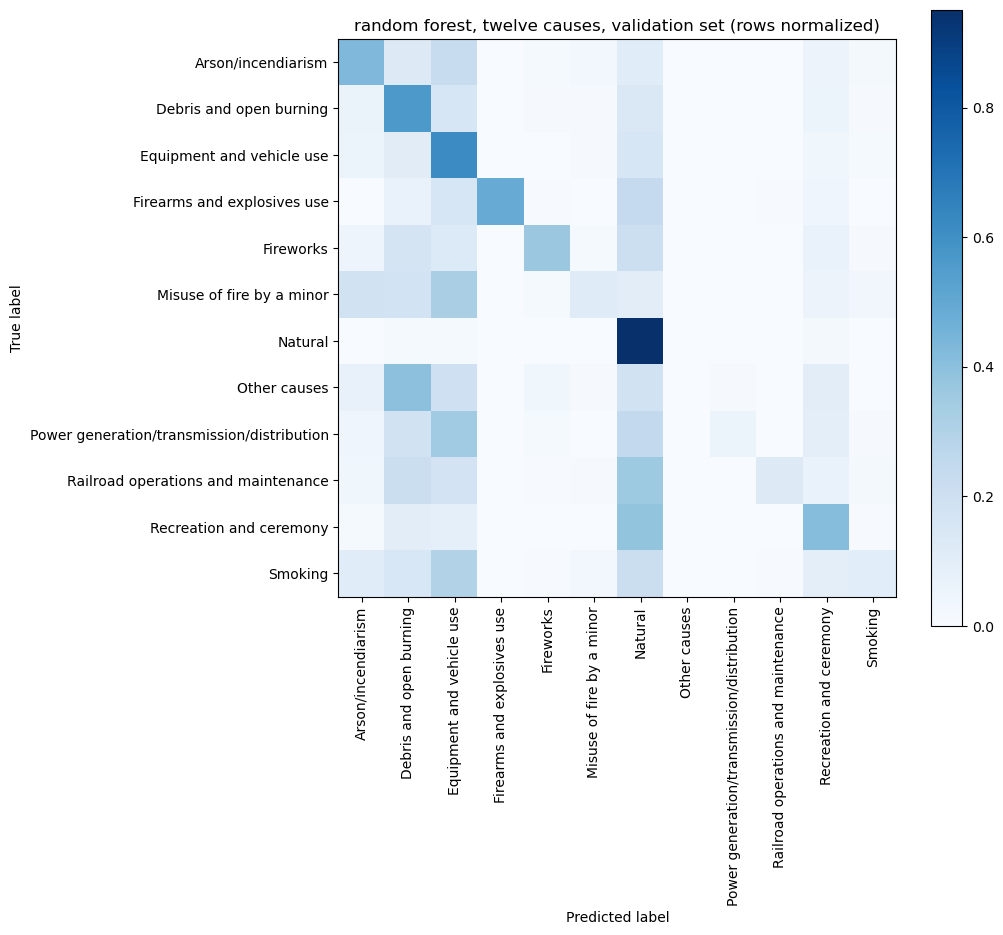

In [14]:
start = time.time()
forest_multi = RandomForestClassifier(n_estimators=30, random_state=42, class_weight="balanced", n_jobs=-1)
forest_multi.fit(X_train, ym_train)
print(f"trained in {time.time() - start:.0f} s  |  validation accuracy {forest_multi.score(X_val, ym_val):.3f}")

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_estimator(forest_multi, X_val, ym_val, normalize="true",
                                      display_labels=classnames_multi, xticks_rotation="vertical",
                                      include_values=False, cmap="Blues", ax=ax)
ax.set_title("random forest, twelve causes, validation set (rows normalized)")
plt.show()

In [15]:
from sklearn.metrics import classification_report

print(classification_report(ym_val, forest_multi.predict(X_val), target_names=classnames_multi, digits=2))

                                            precision    recall  f1-score   support

                        Arson/incendiarism       0.52      0.43      0.47      2737
                   Debris and open burning       0.51      0.56      0.53      4092
                 Equipment and vehicle use       0.50      0.62      0.55      4899
               Firearms and explosives use       0.92      0.49      0.64       150
                                 Fireworks       0.61      0.36      0.45       646
                 Misuse of fire by a minor       0.37      0.11      0.17      1145
                                   Natural       0.80      0.95      0.87     16856
                              Other causes       0.00      0.00      0.00       204
Power generation/transmission/distribution       0.51      0.06      0.10       617
       Railroad operations and maintenance       0.61      0.12      0.21       322
                   Recreation and ceremony       0.58      0.41      0.48  

Natural fires are easy, recall 0.95. Equipment, debris burning, and recreation are middling,
with recall between 0.4 and 0.6. The diffuse causes are hard: smoking, misuse of fire by a
minor, power lines, and "other causes" have recall near or below 0.1. One surprise is firearms
and explosives, which the forest rarely predicts but gets right nine times in ten when it does,
presumably because those fires cluster at a few distinctive sites. Read the row-normalized
matrix for where the missed fires go: mostly into the big human-caused classes that look the
same at the ignition point. The attributes describe where and when a fire started, not who struck the match,
and for many causes that is simply not enough. A model cannot recover information the features
do not carry.

## 9. The point of the paper: label the unknown fires

The forest was trained on fires with a recorded cause. Applying it to the 150,000 fires with no
recorded cause is the inference the paper is about.


In [16]:
pred_unknown = forest_multi.predict(X_unknown)
counts = pd.Series(np.array(classnames_multi)[pred_unknown]).value_counts()
print("predicted causes of the fires with no recorded cause:")
print(counts)
print(f"\npredicted natural: {(counts.get('Natural', 0) / len(pred_unknown)):.1%}  "
      f"(among fires with a recorded cause, {y_binary.mean():.1%} are natural)")

predicted causes of the fires with no recorded cause:
Equipment and vehicle use                     46354
Arson/incendiarism                            29987
Natural                                       29314
Debris and open burning                       24929
Smoking                                        7767
Recreation and ceremony                        7262
Misuse of fire by a minor                      2496
Fireworks                                      1312
Power generation/transmission/distribution      453
Railroad operations and maintenance             143
Firearms and explosives use                      81
Other causes                                     28
Name: count, dtype: int64

predicted natural: 19.5%  (among fires with a recorded cause, 45.6% are natural)


The unknown fires are predicted to be mostly human-caused, with a smaller natural share than
the fires whose cause was recorded. That matches the paper's finding and makes physical sense:
lightning fires in remote country tend to get investigated and recorded, while small
human-caused fires near roads are the ones that go undocumented. The honest caveat is that the
rare causes the model cannot tell apart are folded into the common ones here too.

**Saving a trained model.** Forests on half a million rows take a while to train. `pickle`
writes the fitted object to disk so it can be reloaded without retraining.


In [17]:
import pickle

with open("forest_multi.pkl", "wb") as f:
    pickle.dump(forest_multi, f)
with open("forest_multi.pkl", "rb") as f:
    reloaded = pickle.load(f)
print("reloaded model agrees with the original:", np.array_equal(reloaded.predict(X_val[:1000]), forest_multi.predict(X_val[:1000])))

reloaded model agrees with the original: True


## Exercises

Each one reuses something from above on a different setting. Work in new cells below.


1. **Minimum leaf size.** `max_depth` is not the only way to limit a tree. Train
   `DecisionTreeClassifier` with no depth limit but `min_samples_leaf=50`, and compare its
   training and validation accuracy with the depth-limited best tree. Which knob gives the
   smaller train-validation gap?


2. **Features per split.** The forest's `max_features` sets how many features each split
   may consider; the default for classification is the square root of the number of features.
   Train a 50-tree forest with `max_features=None` (all features at every split) and compare its
   validation accuracy and training time with the default. What does restricting the features
   buy?


3. **Test set, finally.** Score `forest` on the held-out test set with `.score` and show its
   confusion matrix there. Is it close to the validation result? Say in one sentence why the
   test number is the one to report.


4. **Importance without weather.** Drop `vpd`, `erc`, `bi`, `fm100`, `fm1000`, `pr`, `tmmn`,
   and `vs` from the feature list, retrain the binary forest, and compare validation accuracy.
   How much of the skill was weather?


5. **Does class weighting matter?** Retrain the multiclass forest with `class_weight=None`
   and compare the two classification reports. Which classes change the most, and in which
   direction?


6. **Two models on one fire.** Pick one fire from the unknown set, and print the
   `predict_proba` output of the multiclass forest for it alongside `classnames_multi`. How
   confident is the forest, and what does a flat probability vector tell you?
